# Creating Word Vectors with word2vec

#### Install Dependencies

In [1]:
import nltk
from nltk.corpus.reader.plaintext import PlaintextCorpusReader
import gensim
from gensim.models.word2vec import Word2Vec
from sklearn.manifold import TSNE
import pandas as pd
from bokeh.io import output_notebook
from bokeh.plotting import show, figure

#### Load Data

In [2]:
corpus_root = 'C:\\Users\\abhir\\Desktop\\Minor Project\\corpus'

In [3]:
corpus = PlaintextCorpusReader(corpus_root, 'Monolingual_50000.hi')

In [4]:
corpus_sents = corpus.sents()

#### Tokenize Text

In [5]:
len(corpus_sents)

47165

In [6]:
corpus_sents[0:4]

[['भ',
  'ा',
  'रत',
  'ी',
  'य',
  'र',
  'ा',
  'जन',
  'ी',
  'त',
  'ि',
  'म',
  'ें',
  'प',
  'ि',
  'छड',
  '़े',
  'पन',
  'क',
  'े',
  'व',
  'ि',
  'च',
  'ा',
  'र',
  'क',
  'ा',
  'स',
  'ू',
  'त',
  '्',
  'र',
  'ी',
  'करण',
  'उस',
  'े',
  'खत',
  '्',
  'म',
  'करन',
  'े',
  'क',
  'े',
  'मकसद',
  'स',
  'े',
  'क',
  'ि',
  'य',
  'ा',
  'गय',
  'ा',
  'थ',
  'ा',
  'ल',
  'े',
  'क',
  'ि',
  'न',
  'अब',
  'ऐस',
  'ा',
  'लग',
  'रह',
  'ा',
  'ह',
  'ै',
  'क',
  'ि',
  'यह',
  'समझ',
  'ब',
  'ै',
  'कवर',
  '्',
  'डन',
  'े',
  'स',
  'खत',
  '्',
  'म',
  'करन',
  'े',
  'क',
  'े',
  'बज',
  'ा',
  'य',
  'उसक',
  'ी',
  'व',
  'ि',
  'भ',
  'ि',
  'न',
  '्',
  'न',
  'क',
  'ि',
  'स',
  '्',
  'म',
  'ों',
  'क',
  'े',
  'ब',
  'ी',
  'च',
  'ह',
  'ो',
  'ड',
  '़',
  'म',
  'ें',
  'पत',
  'ि',
  'त',
  'ह',
  'ो',
  'गई',
  'ह',
  'ै',
  'ज',
  'ो',
  'प',
  'ि',
  'छड',
  'े़',
  'क',
  'ी',
  'श',
  '्',
  'र',
  'े',
  'ण',
  'ी',
  'म',
  '

In [7]:
corpus_sents[5]

['इसक',
 'े',
 'ल',
 'ि',
 'ए',
 'प',
 'ै',
 'स',
 'ा',
 'क',
 'ि',
 'सक',
 'ी',
 'ज',
 'े',
 'ब',
 'स',
 'े',
 'आएग',
 'ा?']

In [8]:
len(corpus.words())

3759055

#### Run word2vec

In [10]:
model = Word2Vec(sentences=corpus_sents, vector_size=64, sg=1, window=8, min_count=5)

In [11]:
model.save('custom_new_monolingual.model')

In [12]:
model = Word2Vec.load('custom_new_monolingual.model')

In [20]:
model.wv['एक']

array([-0.2047157 ,  0.37852916,  0.47259885, -0.14943121,  0.16247961,
       -0.09613981, -0.21571344,  0.48727533, -0.03507846,  0.01551101,
        0.14969969,  0.09942052,  0.04003038, -0.21507426, -0.16118948,
       -0.09383693, -0.1872927 , -0.05995661,  0.14927377,  0.13369498,
       -0.09550852,  0.2592482 ,  0.06962676, -0.11247259,  0.04810991,
       -0.1163056 , -0.02066059,  0.1430661 ,  0.02716528, -0.03737461,
        0.34100842, -0.07885874, -0.14176907, -0.12339745,  0.14238143,
        0.10569818,  0.13501208,  0.5571744 ,  0.29826757, -0.3452185 ,
       -0.13410653, -0.00670067,  0.0677531 , -0.12278892,  0.03151471,
       -0.03629522,  0.29384348, -0.26999363,  0.02605087, -0.1375675 ,
       -0.2717147 , -0.07053117, -0.05607273,  0.32059738,  0.45205015,
        0.12949234,  0.28862852, -0.26685774, -0.21100229,  0.22097372,
        0.05490287, -0.243347  , -0.2706359 ,  0.20401369], dtype=float32)

In [14]:
model.wv.most_similar('फन')

[('चरर', 0.8932134509086609),
 ('इह', 0.8805976510047913),
 ('सनम', 0.8732704520225525),
 ('इद', 0.8683556318283081),
 ('यरनम', 0.8680239319801331),
 ('ॉ।', 0.8678684234619141),
 ('टमस', 0.8671019077301025),
 ('टरड', 0.8670324087142944),
 ('जयश', 0.8637223243713379),
 ('मफ', 0.8613265156745911)]

#### Reduce word vector dimensionality with T-SNE

In [15]:
len(model.wv.key_to_index) # Words that met the criteria

4178

In [16]:
X = model.wv[model.wv.key_to_index]

In [17]:
tsne = TSNE()

In [18]:
X_2d = tsne.fit_transform(X)

In [19]:
X_2d[0:5]

array([[-37.456078,  15.978955],
       [-37.569725,  14.995677],
       [-36.76395 ,  15.532918],
       [-37.139034,  17.417812],
       [-37.167564,  16.52469 ]], dtype=float32)

In [21]:
coords_df = pd.DataFrame(X_2d, columns=['x', 'y'])
coords_df['token'] = model.wv.key_to_index.keys() # टोकन

In [22]:
coords_df.head()

,x,y,token
0,-37.456078,15.978955,ा
1,-37.569725,14.995677,े
2,-36.763950,15.532918,क
3,-37.139034,17.417812,्
4,-37.167564,16.524691,ि


In [23]:
coords_df.to_csv('custom_new_monolingual.csv', index=False)

#### Visulaize 2D representation of word vectors

In [24]:
coords_df = pd.read_csv('custom_new_monolingual.csv')

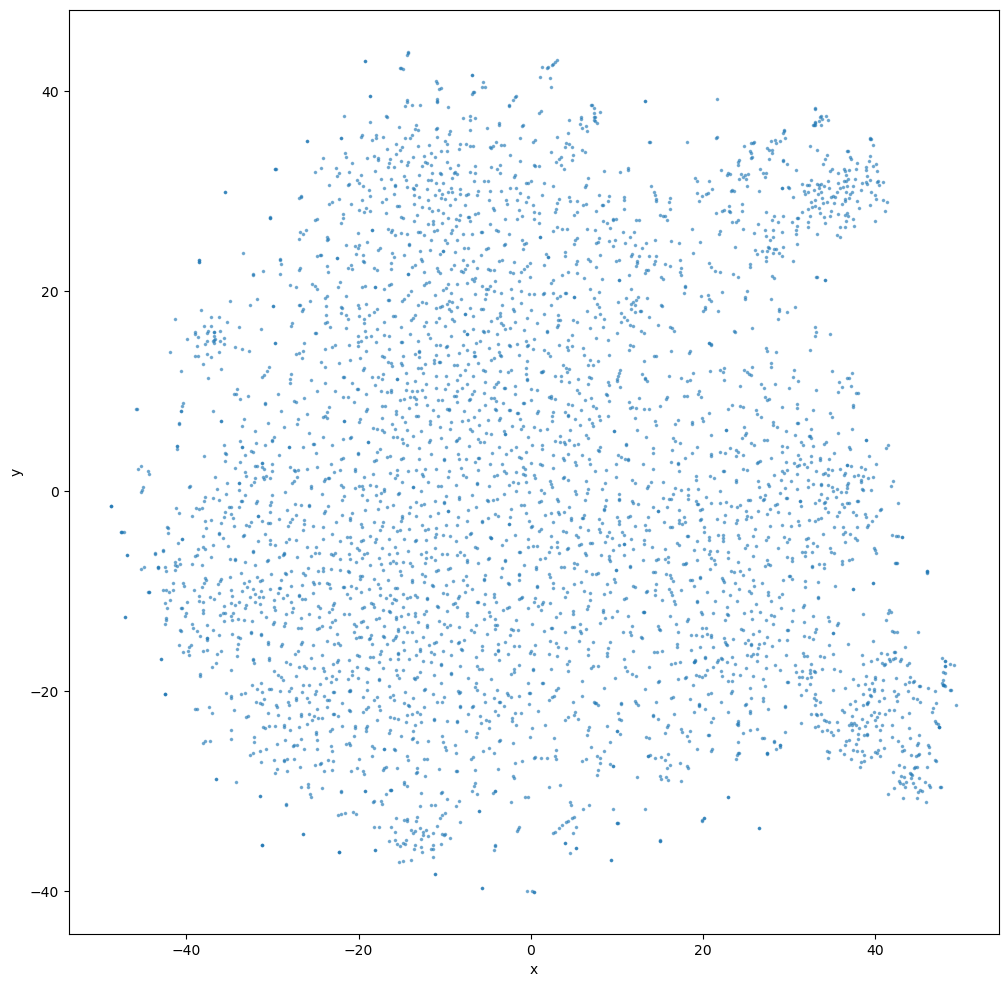

In [25]:
_ = coords_df.plot.scatter('x', 'y', figsize=(12, 12), marker='.', s=10, alpha=0.5)

In [26]:
output_notebook()

Loading BokehJS ...

In [28]:
subset_df = coords_df.sample(n=3000)

In [29]:
p = figure(plot_width=800, plot_height=800)
_ = p.text(x=subset_df.x, y=subset_df.y, text=subset_df.token)

In [30]:
show(p)